# 06 — Consumer Market Segmentation

## Objective

Identify data-driven market archetypes using K-Means clustering, rather than assuming segment definitions in advance. Clustering variables: GDP per capita (PPP), consumption per capita, consumption CAGR, internet penetration, urbanisation, and inflation — all standardised before clustering.

## Choosing k

k was selected by comparing silhouette scores for k=3 through k=7, not assumed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../src/visualisation')
sil = pd.read_csv('../outputs/tables/segmentation_silhouette_scores.csv')
sil

,k,silhouette_score
0,3,0.3131
1,4,0.3213
2,5,0.3058
3,6,0.2668
4,7,0.2708


In [2]:
# House chart style v2 — consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
import matplotlib.pyplot as plt

ACCENT_1 = '#2a78d6'   # primary accent — the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent — used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series — same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## The four resulting segments, visualised via PCA (73% of variance captured in 2 dimensions)

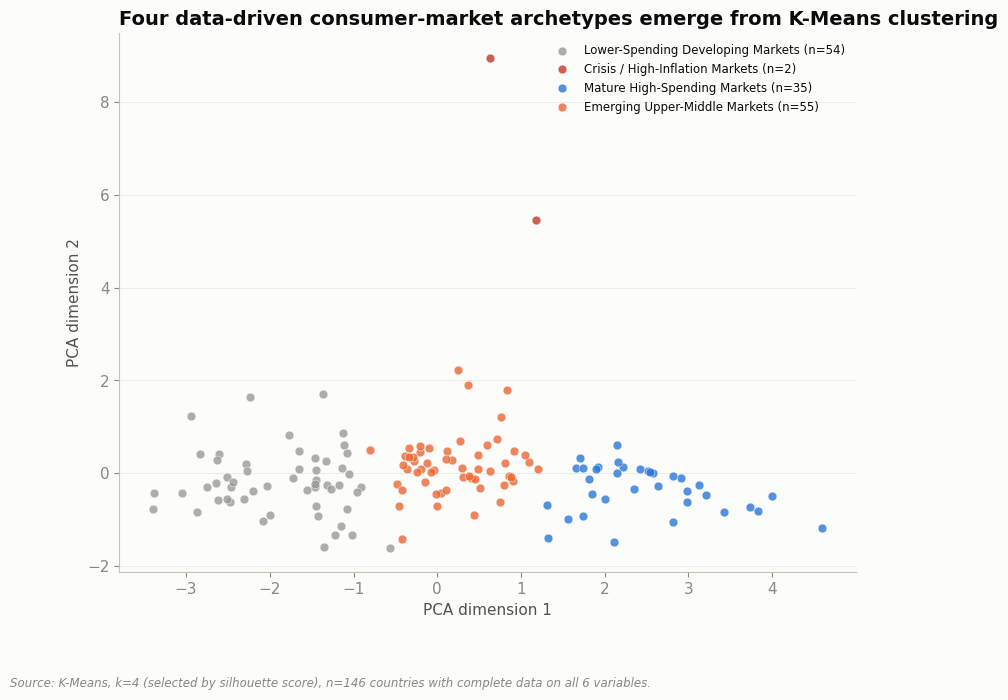

In [3]:
seg = pd.read_csv('../outputs/tables/segmentation_raw.csv')
CLUSTER_NAMES = {0: 'Lower-Spending Developing Markets', 1: 'Crisis / High-Inflation Markets',
                 2: 'Mature High-Spending Markets', 3: 'Emerging Upper-Middle Markets'}
seg['cluster_name'] = seg['cluster'].map(CLUSTER_NAMES)
palette = {0: GRAY, 1: '#c0392b', 2: ACCENT_1, 3: ACCENT_2}
fig, ax = plt.subplots(figsize=(9.5, 7))
for c_id, name in CLUSTER_NAMES.items():
    sub = seg[seg['cluster']==c_id]
    ax.scatter(sub['pca1'], sub['pca2'], s=40, alpha=0.8, color=palette[c_id], label=f'{name} (n={len(sub)})', edgecolor='white', linewidth=0.4)
ax.set_title('Four data-driven consumer-market archetypes emerge from K-Means clustering', loc='left')
ax.set_xlabel('PCA dimension 1'); ax.set_ylabel('PCA dimension 2')
ax.legend(fontsize=8.5)
add_source(ax.figure, 'Source: K-Means, k=4 (selected by silhouette score), n=146 countries with complete data on all 6 variables.')
plt.show()

## Segment Profiles

In [4]:
profiles = pd.read_csv('../outputs/tables/segmentation_cluster_profiles.csv', index_col=0)
profiles.index = profiles.index.map(CLUSTER_NAMES)
profiles.round(1)

,gdp_per_capita_ppp_current_intl,household_consumption_expenditure_per_capita_constant_2015_usd,consumption_cagr_2013_2023_real_pct,internet_users_pct_of_population,urban_population_pct,inflation_cpi_annual_pct,population_total,n_countries
cluster,,,,,,,,
Lower-Spending Developing Markets,6238.6,1332.2,4.3,45.4,42.7,6.3,14258251.0,54
Crisis / High-Inflation Markets,21415.8,7705.0,-0.4,85.5,91.3,177.4,25655947.0,2
Mature High-Spending Markets,71623.8,22906.4,2.1,95.4,85.2,4.0,8888822.0,35
Emerging Upper-Middle Markets,25200.1,5311.6,2.7,84.2,70.3,6.1,7305659.0,55


## Segment Interpretation

**Mature High-Spending Markets (n=35)** — Luxembourg, Singapore, US, Switzerland, Nordics, wealthy Gulf states, developed East Asia. Highest spending power (~$23k/capita), slower growth (~2.1%), near-universal internet and urbanisation. *Behavioural read: price-quality over price-only competition, premiumisation headroom, digital-first expected by default.*

**Emerging Upper-Middle Markets (n=55)** — China, Malaysia, Mexico, Brazil, Central/Eastern Europe, Turkey. Solid growth (~2.7%), mid spending power (~$5.3k/capita), high internet penetration (~84%) already achieved. *Behavioural read: the classic "middle-income consumer" — rising discretionary spending, increasingly digital-first, still price-sensitive relative to Tier 1.*

**Lower-Spending Developing Markets (n=54)** — mostly Sub-Saharan Africa and lower-income South/Southeast Asia. Lowest spending base (~$1.3k/capita) but the **fastest median growth (~4.3%)** — a genuine high-growth-from-a-low-base story. Internet penetration (~45%) and urbanisation (~43%) still have significant room to expand.

**Crisis / High-Inflation Markets (n=2: Argentina, Lebanon)** — a small but analytically real segment. Extreme inflation (>170% median in the observed window) coincides with negative real consumption growth despite otherwise mid-tier income and very high urbanisation/internet penetration. *Behavioural read: normal income-spending relationships break down under macro instability — these markets need to be evaluated on different terms entirely, not benchmarked against the other three segments.*

## Confidence & Caveats

- Clustering used 146 of 182 countries (80%) — 36 were excluded for missing at least one of the six clustering variables, not imputed. See `docs/LIMITATIONS.md`.
- A 2-country cluster is small enough that it is more accurately read as "two notable outliers" than a generalisable market segment — it is reported because it is a real, data-driven result, not smoothed into a larger cluster to look tidier.